# Notebook 3: Combined Model Evaluation

**PronounceAI — Combined Module**

Evaluates all three scoring mechanisms on a held-out test set:

| Scorer | Description |
|---|---|
| Weighted score | `w1*module1 + w2*module2` (no training) |
| Combined RF | Trained Random Forest meta-classifier |
| Combined MLP | Trained PyTorch MLP meta-classifier |

Metrics reported: Accuracy, F1, ROC-AUC, Balanced Accuracy, Confusion Matrix.

> **Prerequisite:** Run notebooks 1 and 2 first.

## Step 1: Imports and Paths

In [1]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')

MODELS_DIR = Path('../models')
for req in ['combined_rf.joblib', 'combined_scaler.joblib', 'combined_features.csv']:
    assert (MODELS_DIR / req).exists(), (
        f'{req} not found. Run notebooks 1 and 2 first.'
    )
print('All required files found.')

All required files found.


## Step 2: Load Models and Data

In [2]:
rf     = joblib.load(MODELS_DIR / 'combined_rf.joblib')
scaler = joblib.load(MODELS_DIR / 'combined_scaler.joblib')

with open(MODELS_DIR / 'combined_config.json') as f:
    config = json.load(f)
print('Config:', config)


class CombinedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 2),
        )
    def forward(self, x):
        return self.net(x)


device = 'cuda' if torch.cuda.is_available() else 'cpu'
net_path = MODELS_DIR / 'combined_net.pt'
net = None
if net_path.exists():
    net = CombinedNet().to(device)
    net.load_state_dict(torch.load(net_path, map_location=device))
    net.eval()
    print('PyTorch MLP loaded.')
else:
    print('combined_net.pt not found — MLP evaluation will be skipped.')

# Load full feature set and do a fresh 80/20 split for eval
df = pd.read_csv(MODELS_DIR / 'combined_features.csv')
from sklearn.model_selection import train_test_split
_, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

X_test = df_test[['module1_score', 'module2_score']].values.astype(np.float32)
y_test = df_test['label'].values
X_test_sc = scaler.transform(X_test)
print(f'Test set: {len(X_test)} samples')

Config: {'features': ['module1_score', 'module2_score'], 'n_features': 2, 'rf_n_estimators': 200, 'rf_max_depth': 8, 'rf_accuracy': 0.925, 'mlp_accuracy': 0.935, 'train_samples': 800, 'test_samples': 200}
PyTorch MLP loaded.
Test set: 200 samples


## Step 3: Run Inference

In [3]:
from sklearn.metrics import roc_curve as _roc_curve

# Random Forest
rf_preds = rf.predict(X_test_sc)
rf_proba = rf.predict_proba(X_test_sc)[:, 1]

# Weighted score (no model — just linear combination)
# Threshold at 50 to produce binary prediction
weighted_proba = (X_test[:, 0] * 0.5 + X_test[:, 1] * 0.5) / 100.0
weighted_preds = (weighted_proba >= 0.5).astype(int)

# PyTorch MLP (if available)
net_preds, net_proba = None, None
if net is not None:
    with torch.no_grad():
        t = torch.tensor(X_test_sc, dtype=torch.float32).to(device)
        net_preds = net(t).argmax(dim=1).cpu().numpy()
        net_proba = torch.softmax(net(t), dim=1)[:, 1].cpu().numpy()

print(f'RF  Accuracy : {accuracy_score(y_test, rf_preds):.4f}')
print(f'WGT Accuracy : {accuracy_score(y_test, weighted_preds):.4f}')
if net_preds is not None:
    print(f'MLP Accuracy : {accuracy_score(y_test, net_preds):.4f}')

RF  Accuracy : 0.9250
WGT Accuracy : 0.8950
MLP Accuracy : 0.9350


## Step 4: Classification Reports

In [4]:
models = [
    ('WEIGHTED SCORE (no model)', weighted_preds, weighted_proba),
    ('COMBINED RANDOM FOREST',    rf_preds,       rf_proba),
]
if net_preds is not None:
    models.append(('COMBINED PYTORCH MLP', net_preds, net_proba))

for name, preds, proba in models:
    auc = roc_auc_score(y_test, proba)
    pr  = average_precision_score(y_test, proba)
    bal = balanced_accuracy_score(y_test, preds)
    print('=' * 55)
    print(name)
    print(classification_report(y_test, preds, target_names=['Degraded', 'Good']))
    print(f'  ROC-AUC           : {auc:.4f}')
    print(f'  PR-AUC            : {pr:.4f}')
    print(f'  Balanced Accuracy : {bal:.4f}')

WEIGHTED SCORE (no model)
              precision    recall  f1-score   support

    Degraded       1.00      0.79      0.88       100
        Good       0.83      1.00      0.90       100

    accuracy                           0.90       200
   macro avg       0.91      0.90      0.89       200
weighted avg       0.91      0.90      0.89       200

  ROC-AUC           : 0.9899
  PR-AUC            : 0.9901
  Balanced Accuracy : 0.8950
COMBINED RANDOM FOREST
              precision    recall  f1-score   support

    Degraded       0.88      0.99      0.93       100
        Good       0.99      0.86      0.92       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.92       200

  ROC-AUC           : 0.9877
  PR-AUC            : 0.9878
  Balanced Accuracy : 0.9250
COMBINED PYTORCH MLP
              precision    recall  f1-score   support

    Degraded       0.94      0.93      0.93    

## Step 5: ROC Curves

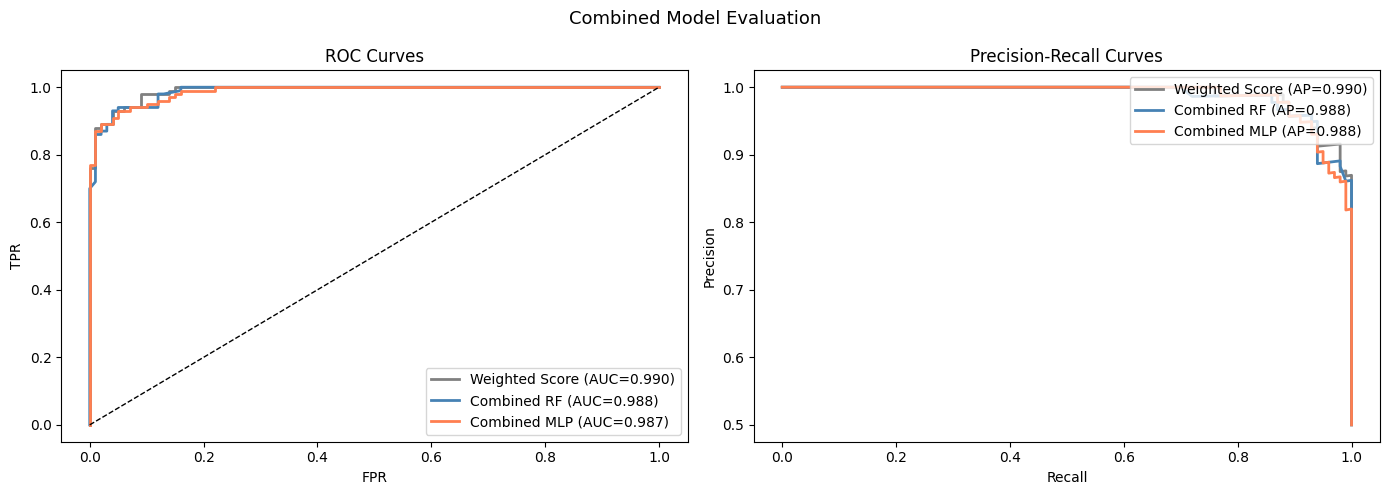

In [5]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_models = [
    ('Weighted Score', weighted_proba, 'gray'),
    ('Combined RF',    rf_proba,       'steelblue'),
]
if net_proba is not None:
    plot_models.append(('Combined MLP', net_proba, 'coral'))

ax = axes[0]
for label, proba, color in plot_models:
    fp, tp, _ = _roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fp, tp, color=color, lw=2, label=f'{label} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves'); ax.legend(loc='lower right')

ax = axes[1]
for label, proba, color in plot_models:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=color, lw=2, label=f'{label} (AP={ap:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves'); ax.legend(loc='upper right')

plt.suptitle('Combined Model Evaluation', fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'combined_roc_curves.png', dpi=120)
plt.show()

## Step 6: Confusion Matrices

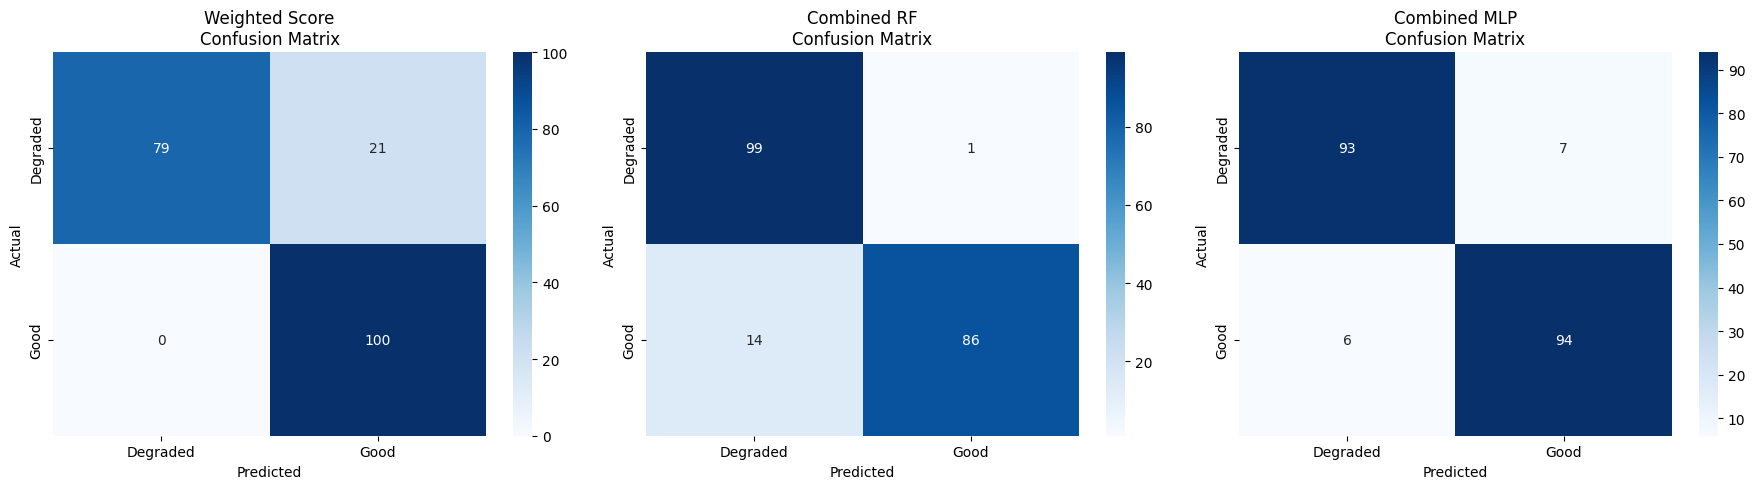

In [6]:
ncols = len(plot_models)
fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
if ncols == 1:
    axes = [axes]

for ax, (name, proba, _), preds in zip(
    axes, plot_models,
    [weighted_preds, rf_preds] + ([net_preds] if net_preds is not None else [])
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Degraded', 'Good'],
                yticklabels=['Degraded', 'Good'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'combined_confusion_matrices_eval.png', dpi=120)
plt.show()